<a href="https://colab.research.google.com/github/giolanta-nta/Homework/blob/main/Week_5_day_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/datajour-gr/ML-algorithms/refs/heads/master/week%205/hour.csv", sep=",")

In [ ]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [ ]:
df.shape

(17379, 17)

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.rename(columns={"hr": "hour", "dteday":"date", "yr":"year",
                            "hum":"humidity", "cnt":"totalcount", "mnth":"month",
                            "weathersit":"weather"}, inplace=True)

bike_rentals  = df.drop(["instant", "date", "year", "registered"],axis=1)

In [13]:
bike_rentals.head()

,season,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,totalcount
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1


In [14]:
bike_rentals.describe()

,season,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,totalcount
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,189.463088
std,1.106918,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,181.387599
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,40.000000
50%,3.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,142.000000
75%,3.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,281.000000
max,4.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,977.000000


In [15]:
bike_rentals.isnull().sum()

,0
season,0
month,0
hour,0
holiday,0
weekday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0


In [16]:
missing_values = ["n/a", "na", "--", 999,9999]
bike_rentals.replace(to_replace = missing_values, value = np.nan, inplace = True)
bike_rentals.dropna(inplace=True)
bike_rentals.reset_index(drop=True, inplace=True)

<Axes: ylabel='Frequency'>

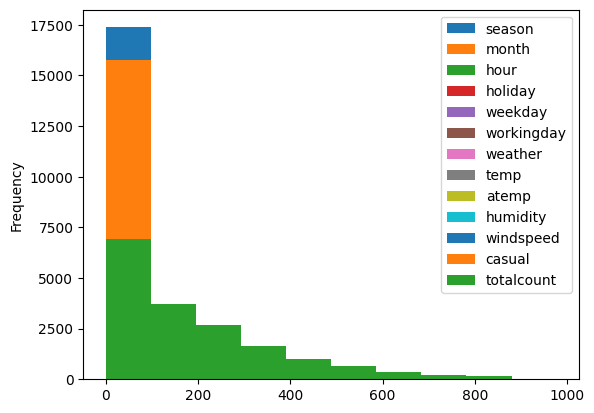

In [17]:
bike_rentals.plot(kind='hist', bins=10)

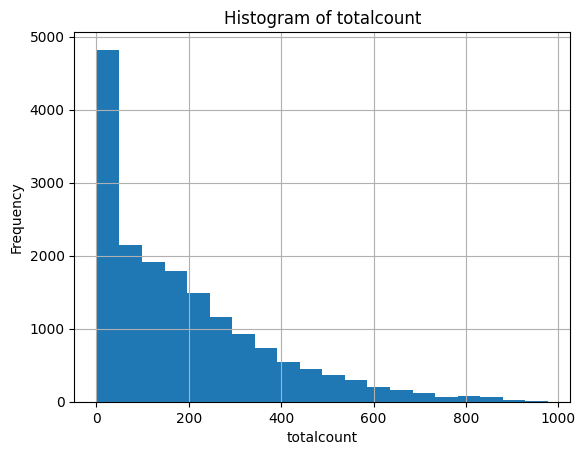

In [18]:
bike_rentals['totalcount'].hist(bins=20)
plt.xlabel('totalcount')
plt.ylabel('Frequency')
plt.title('Histogram of totalcount')
plt.show()

Text(0.5, 1.0, 'Scatterplot of weather and totalcount')

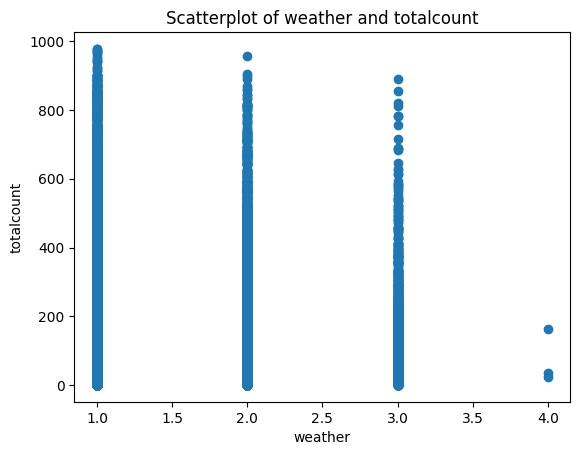

In [19]:
plt.scatter(bike_rentals.weather, bike_rentals.totalcount)
plt.xlabel('weather')
plt.ylabel('totalcount')
plt.title('Scatterplot of weather and totalcount')

Text(0.5, 1.0, 'Scatterplot of temperature and totalcount')

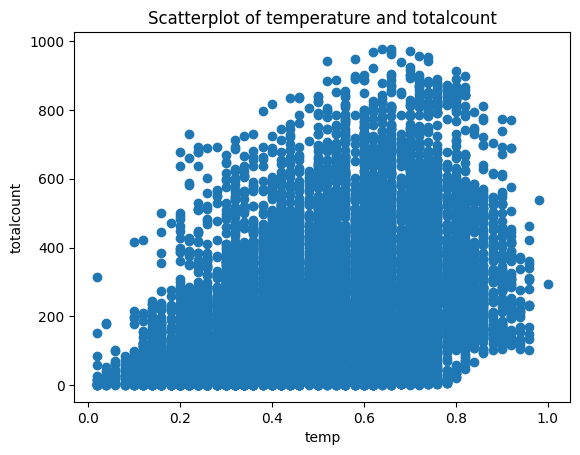

In [20]:
plt.scatter(bike_rentals.temp, bike_rentals.totalcount)
plt.xlabel('temp')
plt.ylabel('totalcount')
plt.title('Scatterplot of temperature and totalcount')

In [21]:
x = bike_rentals[['season', 'month',	'hour',	'holiday',	'weekday',	'workingday',	'weather',	'temp',	'atemp',	'humidity', 'windspeed']]
y = bike_rentals['totalcount']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

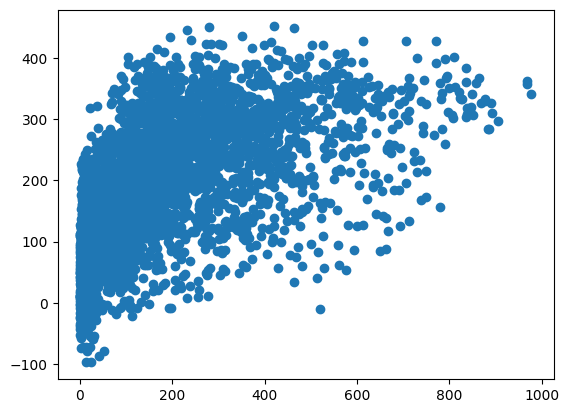

In [23]:
y_pred=model.predict(x_test)
plt.scatter(y_test,y_pred)

In [24]:
mse=mean_squared_error(y_test, y_pred)
r2_score=r2_score(y_test, y_pred)

In [25]:
print(mse)
print(r2_score)

21853.85830858285
0.3449459754123215


In [26]:
lm = LinearRegression()
lm.fit(x_train[['temp']], y_train)
y_pred = lm.predict(x_test[['temp']].values)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

166.3085281498471


In [27]:
lm = LinearRegression()
lm.fit(x_train[['humidity']], y_train)
y_pred = lm.predict(x_test[['humidity']].values)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

172.9420585362914


Text(0.5, 1.0, 'Weather vs Totalcount of Bike Rentals')

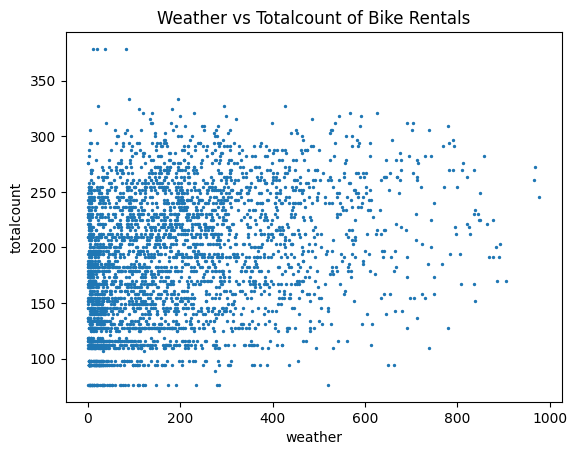

In [28]:
plt.scatter(y_test, y_pred, s = 2)
plt.xlabel("weather")
plt.ylabel("totalcount")
plt.title("Weather vs Totalcount of Bike Rentals")